**This notebook is for analyzing the baseline model (models/baseline) and eventually improving upon it**

Imports:

In [1]:
import numpy as np, joblib, json, tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[16  7  1  2  0]
 [ 4 25  0  5  2]
 [ 0  2 33  2  1]
 [ 4  4  5 37  0]
 [ 0  2  2  2 14]]
              precision    recall  f1-score   support

           0       0.67      0.62      0.64        26
           1       0.62      0.69      0.66        36
           2       0.80      0.87      0.84        38
           3       0.77      0.74      0.76        50
           4       0.82      0.70      0.76        20

    accuracy                           0.74       170
   macro avg       0.74      0.72      0.73       170
weighted avg       0.74      0.74      0.74       170



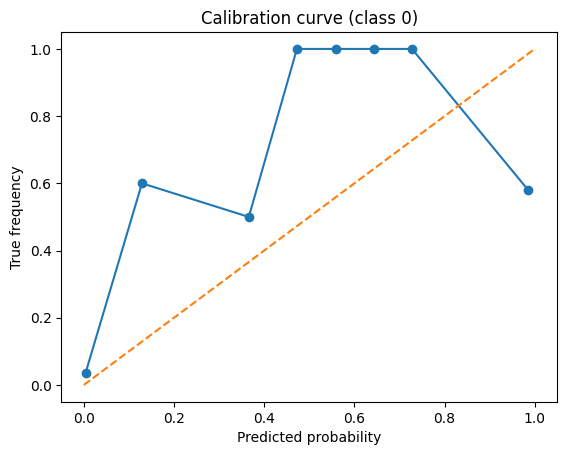

In [3]:

# --- load your saved objects ---
model = tf.keras.models.load_model("models/baseline/model.keras")
bins = np.load("models/baseline/bins.npy")
cfg  = json.load(open("models/baseline/config.json"))

# label_encoder = joblib.load("models/baseline/label_encoder.pkl")  # if you used one
# scaler = joblib.load("models/baseline/scaler.pkl")                # if used

# --- load your test data (same format as training) ---
X_test = np.load("X_test.npy")  # or however you stored it
y_test = np.load("y_test.npy")

# --- get predictions ---
y_pred_proba = model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# --- confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
print(cm)

# --- per-class metrics ---
print(classification_report(y_true, y_pred))

# --- calibration curve (for one class) ---
prob_true, prob_pred = calibration_curve(y_true == 0, y_pred_proba[:,0], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("True frequency")
plt.title("Calibration curve (class 0)")
plt.show()


**Explanation of above results**

*Confusion matrix*

Each row = true class, each column = predicted class.

Diagonal values = correct predictions → overall, quite strong diagonals.

A few key insights:
- Class 2 and 3 perform very well (most predictions on the diagonal).
- Class 0 and Class 1 show some confusion between each other (cross-predictions in [0,1] and [1,0]).
- Class 4 is smaller (20 samples), but still holds up decently.

*Calibration curve*

Your plot shows a blue line that’s not following the orange dashed line (ideal calibration) — meaning the model’s confidence doesn’t match real accuracy.